## Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')   # Disable warning messages to keep output clean

import numpy as np                  # Library for numerical computations and array handling
import pandas as pd                # Library for data manipulation and tabular data processing
import matplotlib.pyplot as plt    # Core plotting library for visualizations
import seaborn as sns              # High-level library for statistical data visualization
%matplotlib inline

# Datasets
from sklearn.datasets import make_blobs, load_iris

# Preprocessing
from sklearn.preprocessing import StandardScaler     # Standardizes features (mean=0, variance=1)
from sklearn.decomposition import PCA                # Reduces dimensionality of data while preserving variance
import sklearn.preprocessing as prep                 # Additional preprocessing utilities

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
# KMeans: centroid-based clustering
# AgglomerativeClustering: hierarchical bottom-up clustering
# DBSCAN: density-based clustering with noise detection

# Evaluation metrics
from sklearn.metrics import silhouette_score, adjusted_rand_score
# silhouette_score: evaluates cluster cohesion and separation
# adjusted_rand_score: compares clustering results with true labels

# Hierarchical clustering utilities
from scipy.cluster.hierarchy import dendrogram, linkage
# dendrogram: visualizes hierarchical clustering tree
# linkage: computes hierarchical clustering structure
import itertools   # Provides tools for efficient looping and combinations

# Other
from plotnine import *
from mpl_toolkits.mplot3d import Axes3D


## Helper Functions

Define reusable visualization functions for different clustering algorithms.

In [2]:
# KMeans cluster display (2D, uses centroid markers)
def display_cluster_kmeans(X, km=None, num_clusters=0):
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0], X[:,1], alpha=alpha, s=s)
    else:
        cmap = plt.cm.get_cmap('tab10', num_clusters)
        for i in range(num_clusters):
            plt.scatter(X[km.labels_ == i, 0], X[km.labels_ == i, 1],
                        color=cmap(i), alpha=alpha, s=s)
            plt.scatter(km.cluster_centers_[i][0], km.cluster_centers_[i][1],
                        color=cmap(i), marker='x', s=100)


# Agglomerative / label-based cluster display (2D)
def display_cluster_labels(X, labels=None, num_clusters=0):
    alpha = 0.5
    s = 20
    if labels is None or num_clusters == 0:
        plt.scatter(X[:,0], X[:,1], alpha=alpha, s=s)
    else:
        cmap = plt.cm.get_cmap('tab10', num_clusters)
        for i in range(num_clusters):
            plt.scatter(X[labels == i, 0], X[labels == i, 1],
                        color=cmap(i), alpha=alpha, s=s)


# DBSCAN cluster display (2D, marks noise points)
def display_cluster_dbscan(X, labels, title=""):
    alpha = 0.5
    s = 20
    num_clusters = len(np.unique(labels[labels >= 0]))
    cmap = plt.cm.get_cmap('tab10', num_clusters if num_clusters > 0 else 1)
    for i in np.unique(labels):
        if i == -1:
            plt.scatter(X[labels == i, 0], X[labels == i, 1],
                        c='k', alpha=0.3, s=s, label='Noise')
        else:
            plt.scatter(X[labels == i, 0], X[labels == i, 1],
                        color=cmap(i), alpha=alpha, s=s, label=f'Cluster {i}')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend(loc='upper right', fontsize=8)
    plt.show()




In [3]:
# PCA-projected KMeans display (for high-dim data)
def display_cluster_pca(X, km=None, num_clusters=0):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=alpha, s=s)
    else:
        cmap = plt.cm.get_cmap('tab10', num_clusters)
        for i in range(num_clusters):
            plt.scatter(X_pca[km.labels_ == i, 0], X_pca[km.labels_ == i, 1],
                        color=cmap(i), alpha=alpha, s=s)
            center_pca = pca.transform(km.cluster_centers_[i].reshape(1, -1))
            plt.scatter(center_pca[0, 0], center_pca[0, 1],
                        color=cmap(i), marker='x', s=100)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")


# PCA-projected label display (for high-dim agglomerative / dbscan)
def display_cluster_pca_labels(X, labels=None, num_clusters=0):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    alpha = 0.5
    s = 20
    if labels is None or num_clusters == 0:
        plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=alpha, s=s)
    else:
        cmap = plt.cm.get_cmap('tab10', num_clusters)
        for i in range(num_clusters):
            plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1],
                        color=cmap(i), alpha=alpha, s=s)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")


# PCA-projected DBSCAN display (for high-dim data)
def display_cluster_dbscan_pca(X, labels, title=""):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    alpha = 0.5
    s = 20
    num_clusters = len(np.unique(labels[labels >= 0]))
    cmap = plt.cm.get_cmap('tab10', num_clusters if num_clusters > 0 else 1)
    for i in np.unique(labels):
        if i == -1:
            plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1],
                        c='k', alpha=0.3, s=s, label='Noise')
        else:
            plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1],
                        color=cmap(i), alpha=alpha, s=s, label=f'Cluster {i}')
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend(loc='upper right', fontsize=8)
    plt.show()

---
# Section 3: Customer Dataset

Repeat all clustering approaches on the Customer dataset.

### 3.1 Data Loading & Preprocessing

In [4]:
df = pd.read_csv("Customer data.csv")
print(df.dtypes)
df.head()

ID                 int64
Sex                int64
Marital status     int64
Age                int64
Education          int64
Income             int64
Occupation         int64
Settlement size    int64
dtype: object


,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


In [5]:
# Prepare data for modeling by dropping 'ID' column (if it exists) and scaling features
df_model = df.drop(columns=['ID'], errors='ignore')  # Drop ID; ignore if not present

# Standardize features to zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

# Create a DataFrame with scaled features for easier inspection
df_scaled = pd.DataFrame(X_scaled, columns=df_model.columns)
df_scaled.head()  # Display first few rows of scaled data

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,-0.917399,-0.993024,2.653614,1.604323,0.097524,0.296823,1.552326
1,1.090038,1.007025,-1.187132,-0.063372,0.782654,0.296823,1.552326
2,-0.917399,-0.993024,1.117316,-0.063372,-0.833202,-1.269525,-0.909730
3,-0.917399,-0.993024,0.775916,-0.063372,1.328386,0.296823,0.321298
4,-0.917399,-0.993024,1.458716,-0.063372,0.736932,0.296823,0.321298


In [6]:
# Drop ID column
df_model = df.drop(columns=['ID'], errors='ignore')

# Columns to scale
cols_to_scale = ['Age', 'Education', 'Income', 'Occupation', 'Settlement size']  # numeric/ordinal

# Columns to leave as-is
cols_no_scale = ['Sex', 'Marital status']

# Apply StandardScaler only to numeric columns
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_model[cols_to_scale])
df_scaled = pd.DataFrame(scaled_values, columns=cols_to_scale)

# Add the unscaled binary columns back
df_scaled[cols_no_scale] = df_model[cols_no_scale].reset_index(drop=True)

df_scaled.head()

,Age,Education,Income,Occupation,Settlement size,Sex,Marital status
0,2.653614,1.604323,0.097524,0.296823,1.552326,0,0
1,-1.187132,-0.063372,0.782654,0.296823,1.552326,1,1
2,1.117316,-0.063372,-0.833202,-1.269525,-0.909730,0,0
3,0.775916,-0.063372,1.328386,0.296823,0.321298,0,0
4,1.458716,-0.063372,0.736932,0.296823,0.321298,0,0


### 3.2 K-Means — Scaled Data

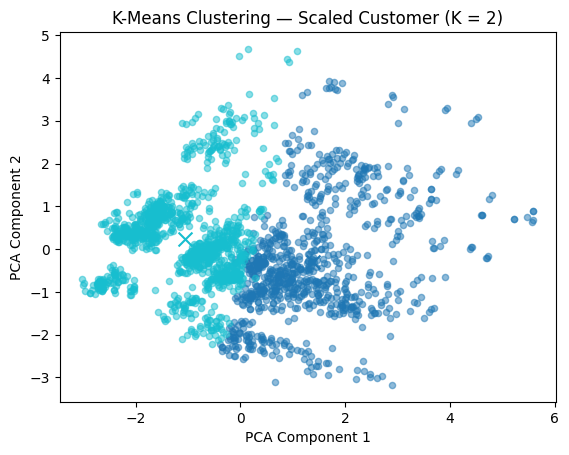

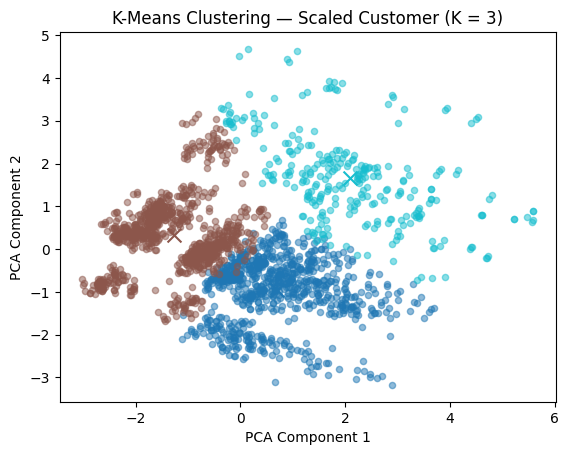

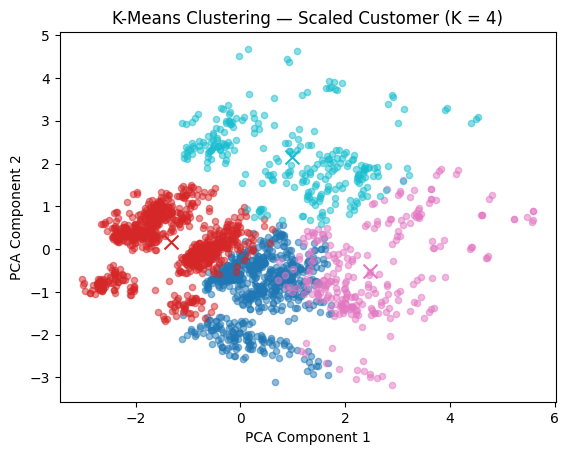

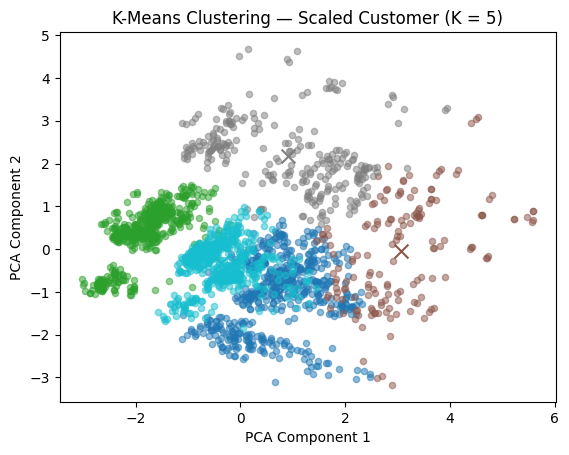

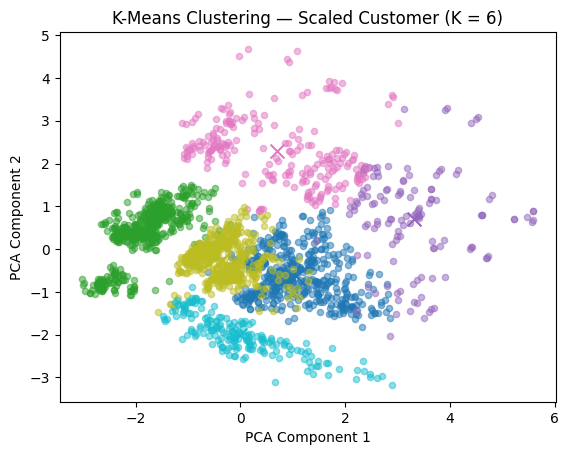

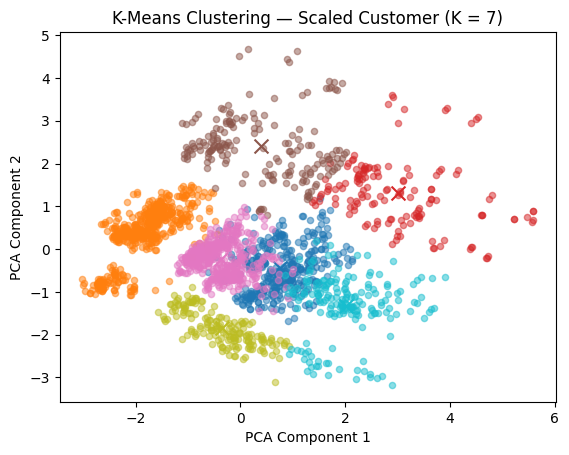

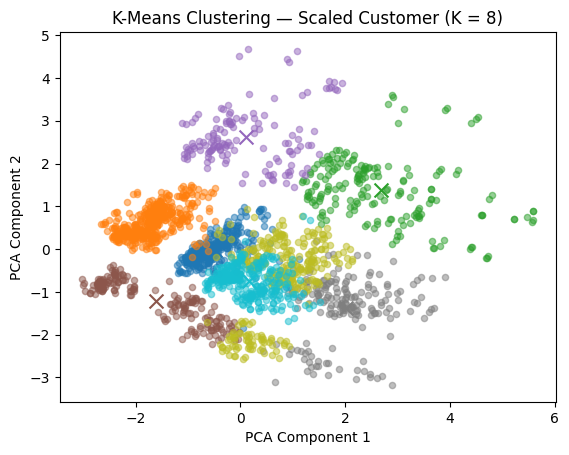

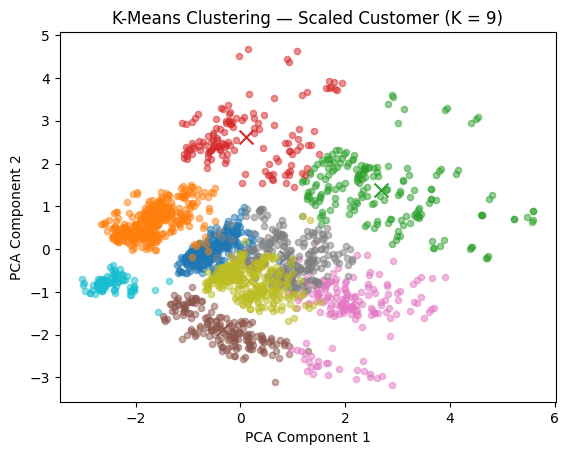

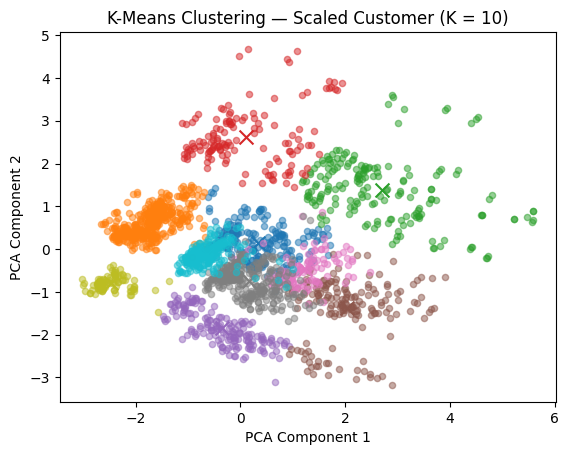

In [7]:
# Run K-Means clustering for a range of K values on scaled customer data
K_range = range(2, 11)
distortions = []  # Store inertia (sum of squared distances)
sil_scores = []   # Store silhouette scores

for K in K_range:
    # Initialize K-Means with k clusters and k-means++ initialization
    km = KMeans(n_clusters=K, init='k-means++', random_state=42)

    # Fit the model on scaled data
    km.fit(df_scaled)

    # Record inertia and silhouette score
    distortions.append(km.inertia_)
    sil_scores.append(silhouette_score(df_scaled, km.labels_))

    # Visualize clusters in PCA-reduced space
    plt.figure()
    display_cluster_pca(df_scaled, km, K)
    plt.title(f"K-Means Clustering — Scaled Customer (K = {K})")
    plt.show()

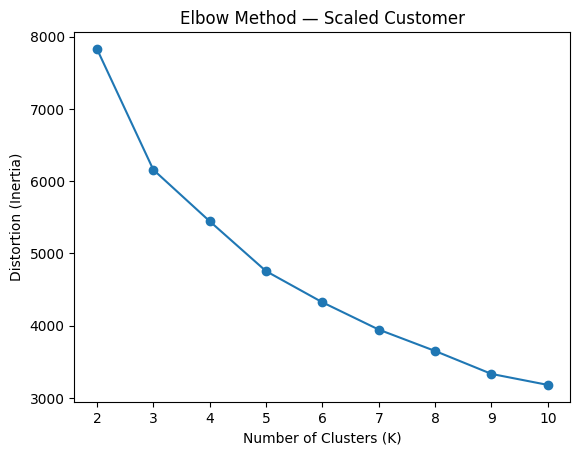

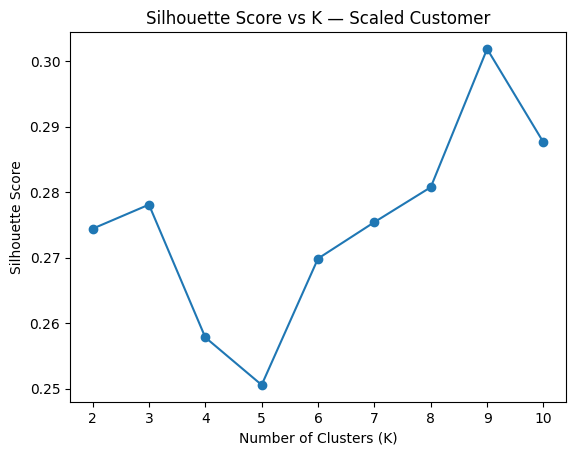

In [8]:
# Plot the Elbow Method to find optimal K for K-Means
plt.figure()
plt.plot(K_range, distortions, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Distortion (Inertia)")
plt.title("Elbow Method — Scaled Customer")
plt.show()

# Plot silhouette scores vs K to help select the best number of clusters
plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K — Scaled Customer")
plt.show()

Best K: 9
Best Silhouette Score: 0.30186803266496826


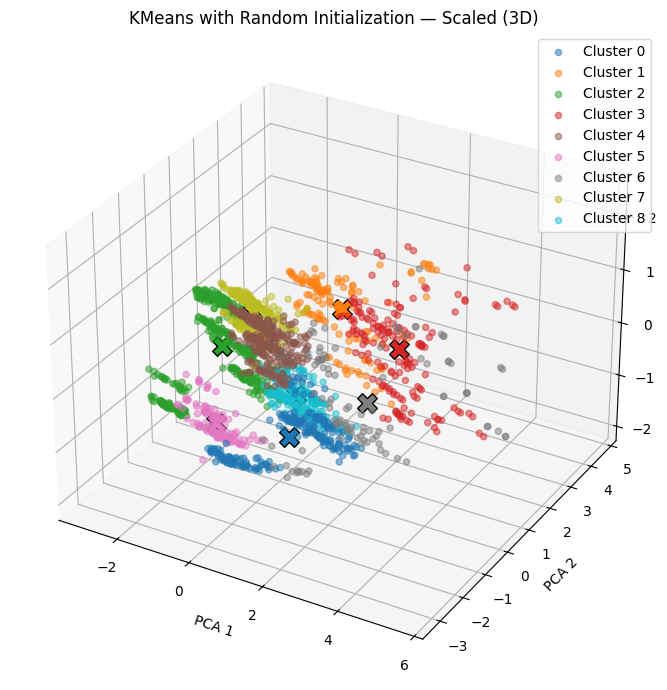

Inertia (Random): 3509.588674136083


In [9]:
# Assume K_range and sil_scores are already defined
K_range = range(2, 11)  # 2 to 10 clusters
# sil_scores is a list of silhouette scores for each K

# 1. Find the K(s) with maximum silhouette
max_sil = np.max(sil_scores)
best_Ks = [k for k, s in zip(K_range, sil_scores) if s == max_sil]

# 2. Pick the smallest K (optional)
best_K = min(best_Ks)
best_silhouette_score = max_sil

print("Best K:", best_K)
print("Best Silhouette Score:", best_silhouette_score)

# 3D PCA visualization with random initialization
km_random = KMeans(n_clusters=best_K, init='random', n_init=1, random_state=42)
km_random.fit(df_scaled)

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(df_scaled)
centers_pca3 = pca3.transform(km_random.cluster_centers_)
cmap = plt.cm.get_cmap('tab10', best_K)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
for i in range(best_K):
    ax.scatter(X_pca3[km_random.labels_ == i, 0],
               X_pca3[km_random.labels_ == i, 1],
               X_pca3[km_random.labels_ == i, 2],
               color=cmap(i), alpha=0.5, s=20, label=f'Cluster {i}')
    ax.scatter(centers_pca3[i, 0], centers_pca3[i, 1], centers_pca3[i, 2],
               color=cmap(i), marker='X', s=200, edgecolors='black')
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("KMeans with Random Initialization — Scaled (3D)")
ax.legend()
plt.tight_layout()
plt.show()
print("Inertia (Random):", km_random.inertia_)

In [10]:
best_silhouette_scaled_kmeans_customer=best_silhouette_score
display(best_silhouette_scaled_kmeans_customer)

np.float64(0.30186803266496826)

### 3.3 K-Means — Unscaled Data

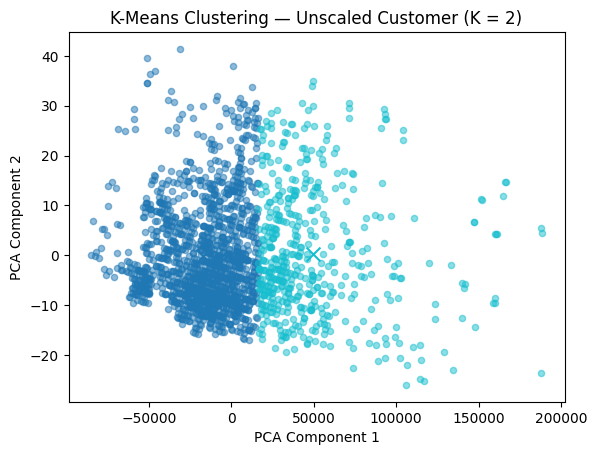

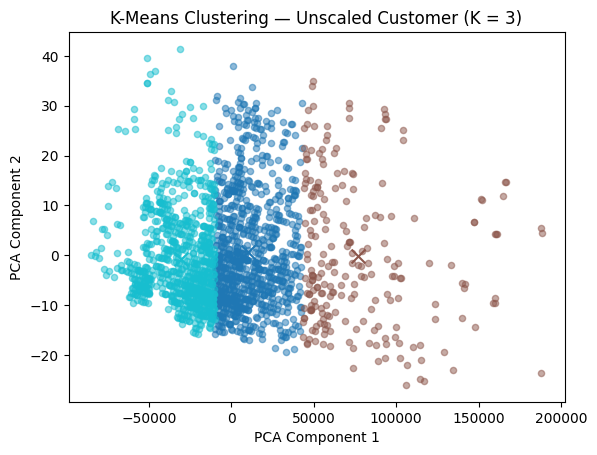

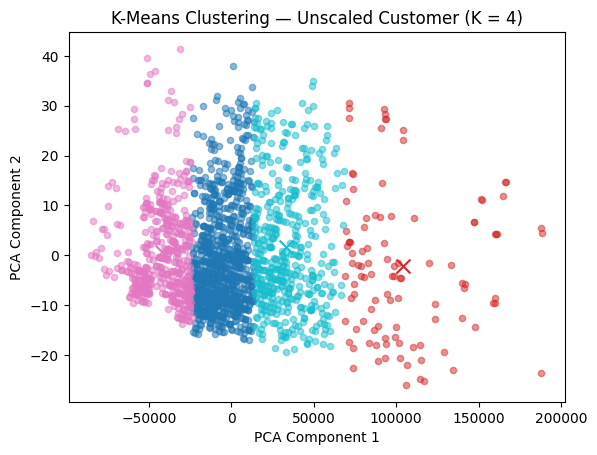

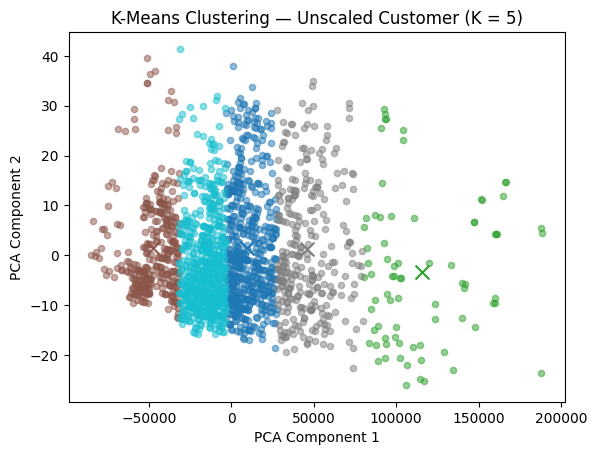

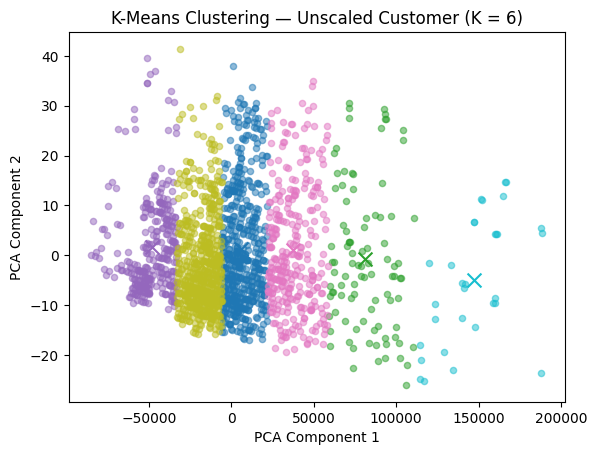

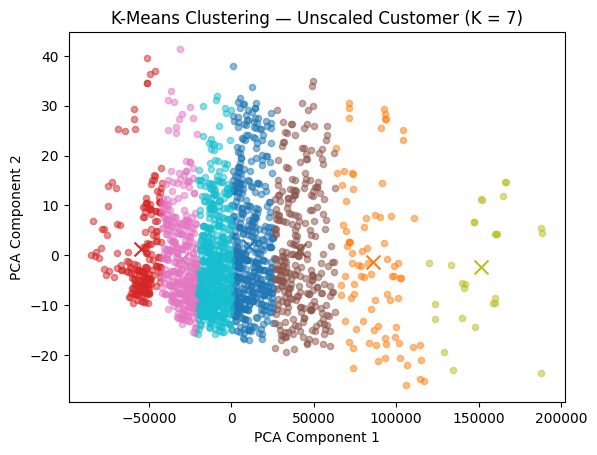

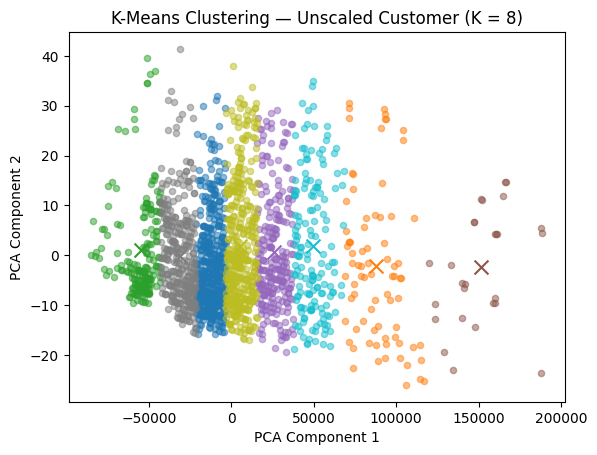

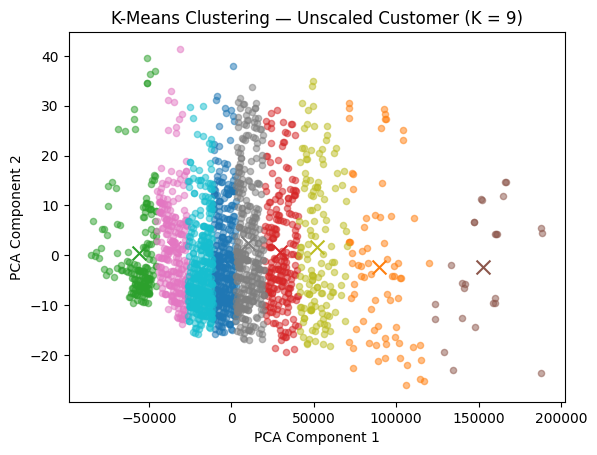

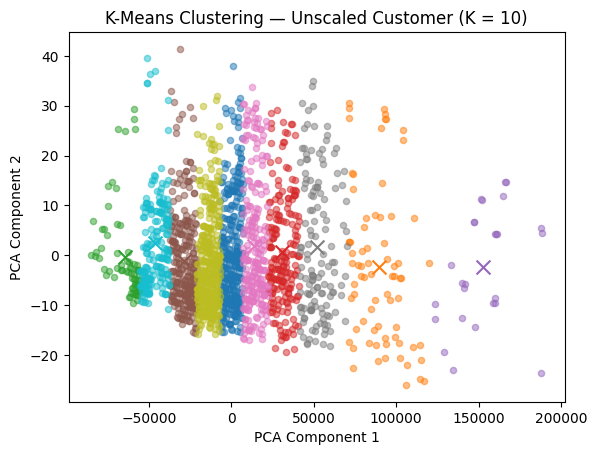

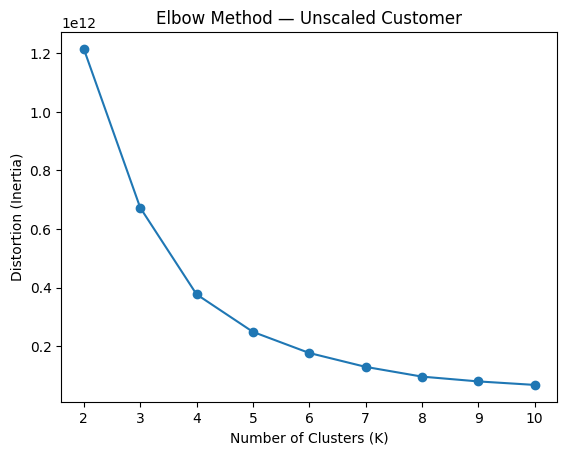

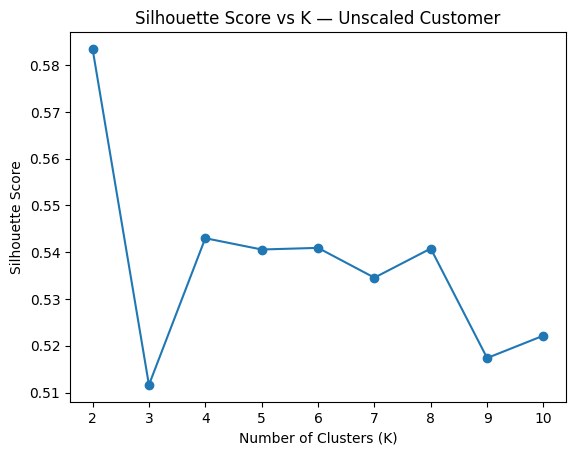

Best K: 2
Best Silhouette Score: 0.5834469001696239


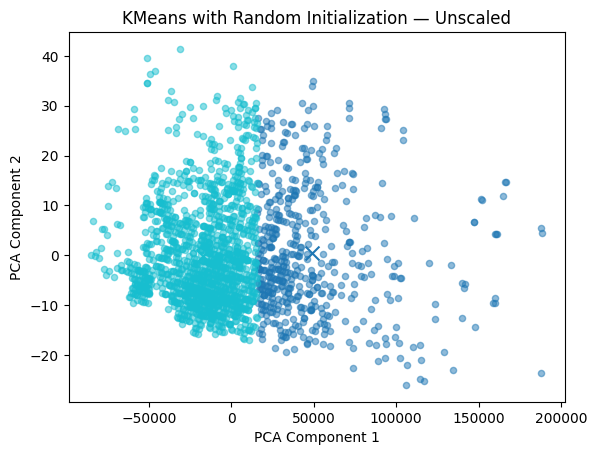

Inertia (Random): 1214625235167.7095


In [11]:
# K-Means clustering on unscaled customer data
K_range = range(2, 11)
distortions = []  # Store inertia
sil_scores = []   # Store silhouette scores

for K in K_range:
    # Initialize K-Means
    km = KMeans(n_clusters=K, init='k-means++', random_state=42)

    # Fit on unscaled data
    km.fit(df_model.values)

    # Record metrics
    distortions.append(km.inertia_)
    sil_scores.append(silhouette_score(df_model.values, km.labels_))

    # Visualize clusters in PCA space
    plt.figure()
    display_cluster_pca(df_model.values, km, K)
    plt.title(f"K-Means Clustering — Unscaled Customer (K = {K})")
    plt.show()

# Plot Elbow method
plt.figure()
plt.plot(K_range, distortions, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Distortion (Inertia)")
plt.title("Elbow Method — Unscaled Customer")
plt.show()

# Plot silhouette scores
plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K — Unscaled Customer")
plt.show()

# Select best K based on silhouette score
best_index = np.argmax(sil_scores)
best_K = list(K_range)[best_index]
best_silhouette_score = sil_scores[best_index]
print("Best K:", best_K)
print("Best Silhouette Score:", best_silhouette_score)

# K-Means with random initialization using the best K
km_random = KMeans(n_clusters=best_K, init='random', n_init=1, random_state=42)
km_random.fit(df_model.values)

# Visualize clusters with random initialization
plt.figure()
display_cluster_pca(df_model.values, km_random, best_K)
plt.title("KMeans with Random Initialization — Unscaled")
plt.show()

# Print inertia for random initialization
print("Inertia (Random):", km_random.inertia_)

### 3.4 Agglomerative Clustering — Scaled Data

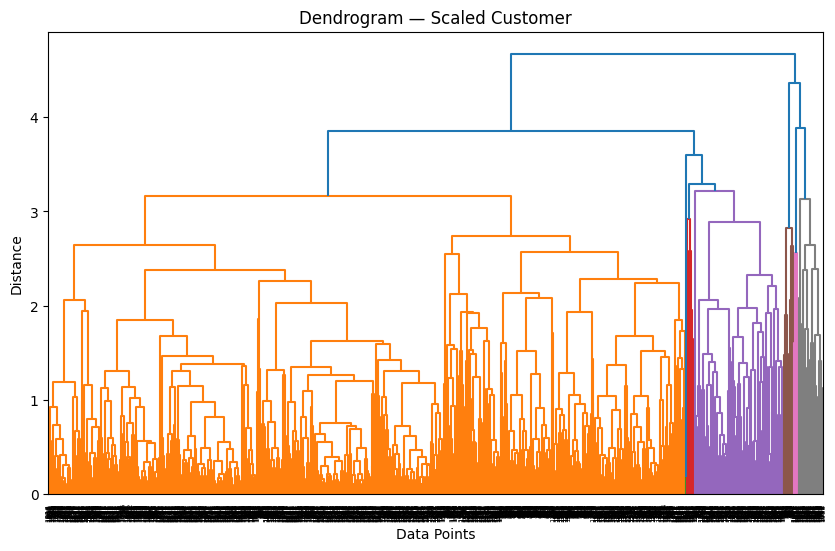

In [12]:
# Hierarchical clustering (Agglomerative) dendrogram for scaled customer data
linked = linkage(df_scaled, method='average', metric='euclidean')

plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title("Dendrogram — Scaled Customer")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

Metric=euclidean, Linkage=ward, Clusters=2, Silhouette=0.3262
Metric=euclidean, Linkage=ward, Clusters=3, Silhouette=0.2556
Metric=euclidean, Linkage=ward, Clusters=4, Silhouette=0.2212
Metric=euclidean, Linkage=ward, Clusters=5, Silhouette=0.2328
Metric=euclidean, Linkage=ward, Clusters=6, Silhouette=0.2507
Metric=euclidean, Linkage=ward, Clusters=7, Silhouette=0.2707
Metric=euclidean, Linkage=ward, Clusters=8, Silhouette=0.2559
Metric=euclidean, Linkage=ward, Clusters=9, Silhouette=0.2787
Metric=euclidean, Linkage=ward, Clusters=10, Silhouette=0.2826
Metric=euclidean, Linkage=average, Clusters=2, Silhouette=0.3497
Metric=euclidean, Linkage=average, Clusters=3, Silhouette=0.2840
Metric=euclidean, Linkage=average, Clusters=4, Silhouette=0.2732
Metric=euclidean, Linkage=average, Clusters=5, Silhouette=0.2545
Metric=euclidean, Linkage=average, Clusters=6, Silhouette=0.2482
Metric=euclidean, Linkage=average, Clusters=7, Silhouette=0.2303
Metric=euclidean, Linkage=average, Clusters=8, Silh

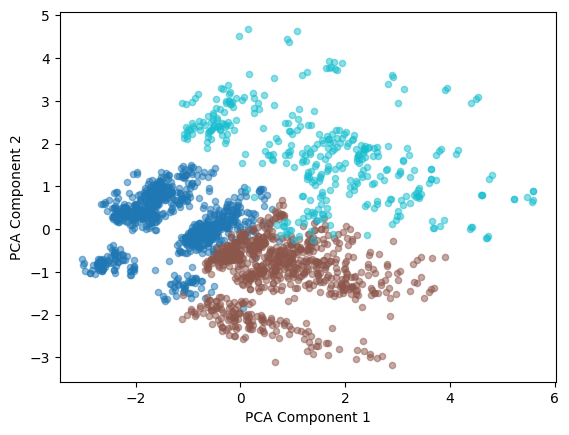

In [13]:
# Agglomerative clustering on scaled customer data with multiple metrics and linkage methods
metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'average', 'complete']

best_score = -1
best_params = None
results = []

# Loop over metrics, linkage methods, and number of clusters
for metric in metrics:
    for linkage_method in linkages:
        if linkage_method == 'ward' and metric != 'euclidean':
            continue  # Ward linkage requires Euclidean distance
        for n_clusters in range(2, 16):  # Test 2 to 15 clusters
            try:
                # Initialize Agglomerative Clustering
                agg = AgglomerativeClustering(
                    n_clusters=n_clusters,
                    metric=metric,
                    linkage=linkage_method
                )

                # Fit model and get labels
                labels = agg.fit_predict(df_scaled)
                num_clusters = len(np.unique(labels))

                # Skip results with too few or too many clusters
                if num_clusters < 2 or num_clusters > 10:
                    continue

                # Compute silhouette score
                sil = silhouette_score(df_scaled, labels, metric=metric)
                results.append((metric, linkage_method, n_clusters, sil))

                print(f"Metric={metric}, Linkage={linkage_method}, Clusters={num_clusters}, Silhouette={sil:.4f}")

                # Track the best configuration
                if sil > best_score:
                    best_score = sil
                    best_params = (metric, linkage_method, num_clusters)
                    best_labels = labels  # store best labels

            except Exception as e:
                print(f"Error: {e}")

# Print best result
print("\nBest Parameters:", best_params)
print("Best Silhouette Score:", best_score)


# Count number of points in each cluster
cluster_counts = pd.Series(best_labels).value_counts().sort_index()
print("\nCluster counts:")
print(cluster_counts)


# PCA 2D visualization for the best clustering
display_cluster_pca_labels(df_scaled, labels=best_labels, num_clusters=len(np.unique(best_labels)))

Metric=euclidean, Linkage=average, Clusters=2, Silhouette=0.3497

Cluster counts:
0     102
1    1898
Name: count, dtype: int64


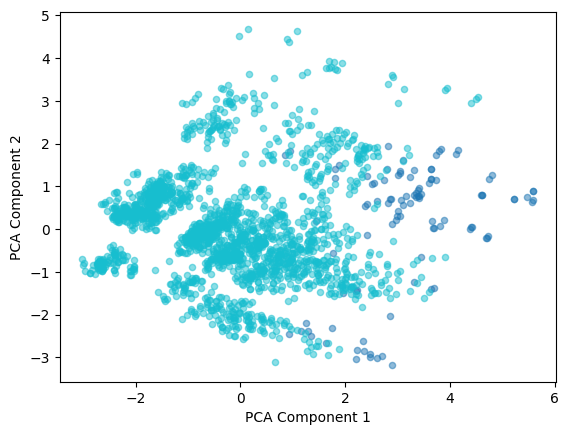

In [14]:
# Agglomerative Clustering with chosen parameters on scaled customer data
metric = 'euclidean'
linkage_method = 'average'
n_clusters = 2

# Initialize and fit Agglomerative Clustering
agg = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric=metric,
    linkage=linkage_method
)
labels = agg.fit_predict(df_scaled)

# Compute silhouette score
sil = silhouette_score(df_scaled, labels, metric=metric)
print(f"Metric={metric}, Linkage={linkage_method}, Clusters={n_clusters}, Silhouette={sil:.4f}")


# Count points in each cluster
cluster_counts = pd.Series(labels).value_counts().sort_index()
print("\nCluster counts:")
print(cluster_counts)


# Visualize clusters in PCA-reduced 2D space
display_cluster_pca_labels(df_scaled, labels=labels, num_clusters=n_clusters)

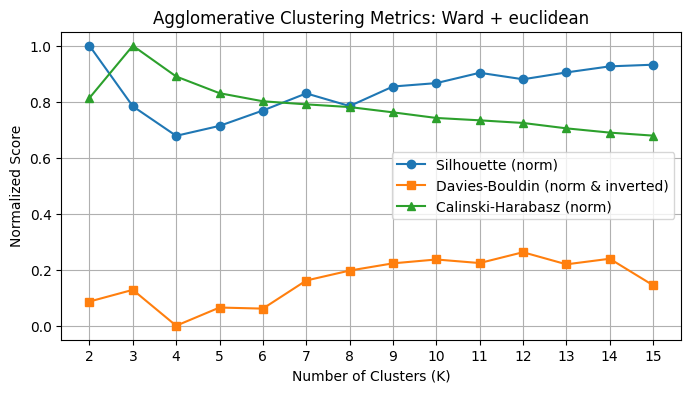

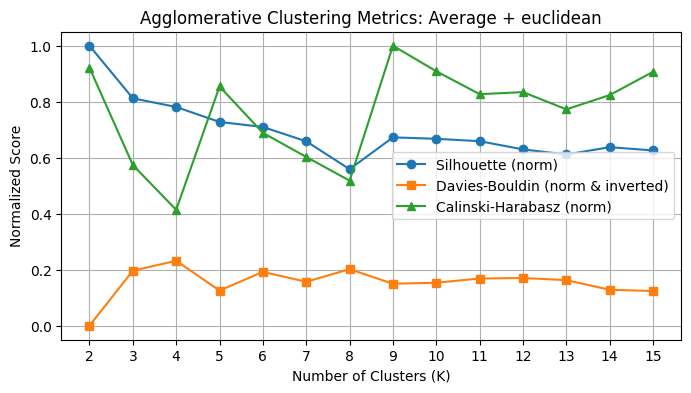

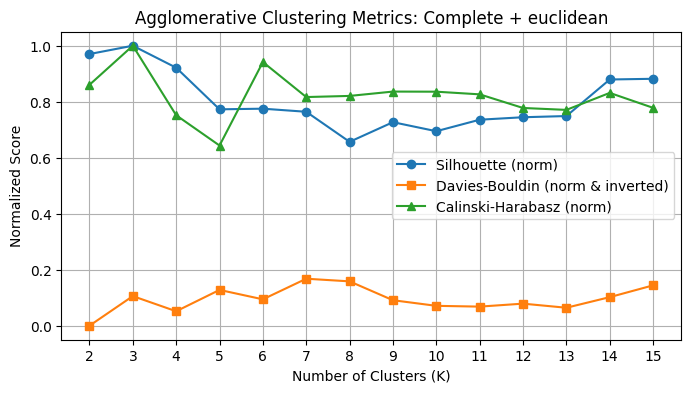

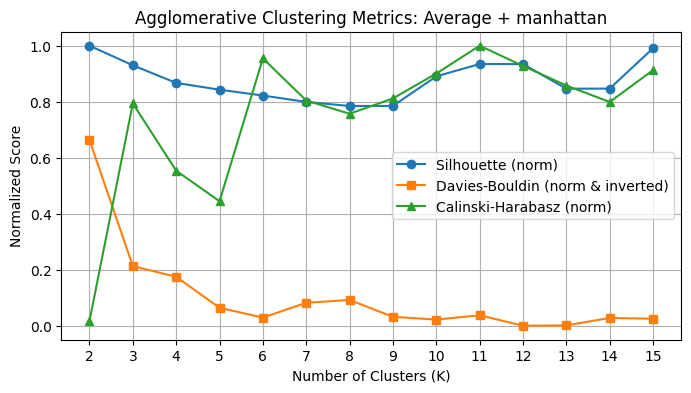

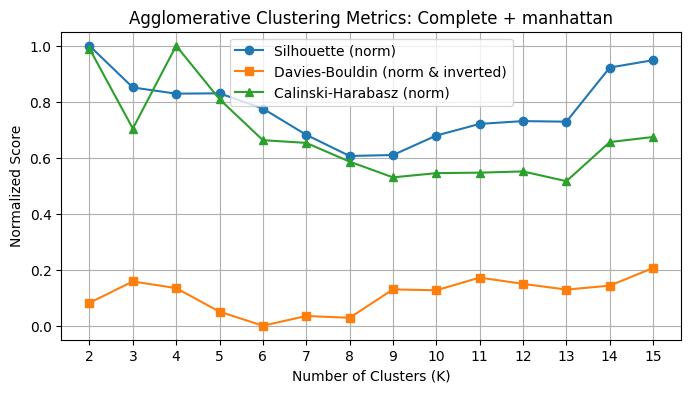

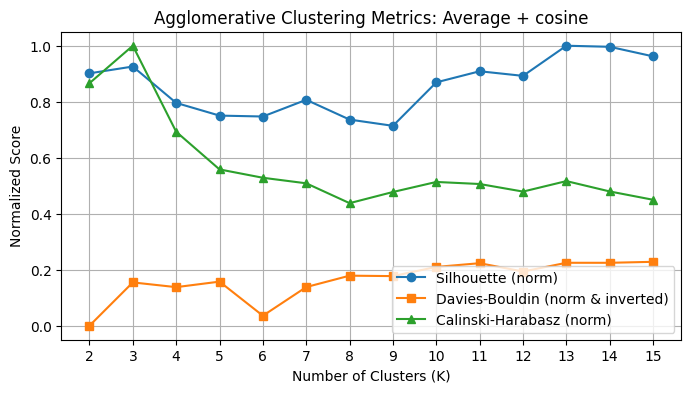

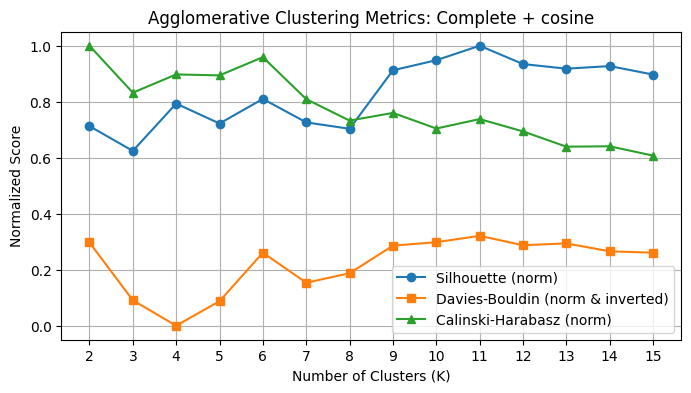

In [15]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Parameters
metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'average', 'complete']
k_values = range(2, 16)

# Store results
results = []

# 2. Grid search over metrics, linkages, and K
for metric in metrics:
    for linkage_method in linkages:
        if linkage_method == 'ward' and metric != 'euclidean':
            continue  # Ward only supports Euclidean

        sil_scores = []
        db_scores = []
        ch_scores = []

        for k in k_values:
            try:
                agg = AgglomerativeClustering(
                    n_clusters=k,
                    linkage=linkage_method,
                    metric=metric
                )
                labels = agg.fit_predict(df_scaled)

                # Only compute if >1 cluster
                if len(np.unique(labels)) > 1:
                    sil = silhouette_score(df_scaled, labels, metric=metric)
                    db = davies_bouldin_score(df_scaled, labels)
                    ch = calinski_harabasz_score(df_scaled, labels)
                else:
                    sil, db, ch = np.nan, np.nan, np.nan

                sil_scores.append(sil)
                db_scores.append(db)
                ch_scores.append(ch)

            except Exception as e:
                print(f"Error for {metric}-{linkage_method}-k={k}: {e}")
                sil_scores.append(np.nan)
                db_scores.append(np.nan)
                ch_scores.append(np.nan)

        # Normalize for plotting
        sil_norm = [s / np.nanmax(sil_scores) for s in sil_scores]
        db_norm = [1 - (d / np.nanmax(db_scores)) for d in db_scores]  # invert DB
        ch_norm = [c / np.nanmax(ch_scores) for c in ch_scores]

        # Store results for later inspection
        results.append({
            'metric': metric,
            'linkage': linkage_method,
            'K': list(k_values),
            'sil': sil_scores,
            'db': db_scores,
            'ch': ch_scores
        })


        # 3. Plot per combination
        plt.figure(figsize=(8,4))
        plt.plot(k_values, sil_norm, marker='o', label='Silhouette (norm)')
        plt.plot(k_values, db_norm, marker='s', label='Davies-Bouldin (norm & inverted)')
        plt.plot(k_values, ch_norm, marker='^', label='Calinski-Harabasz (norm)')

        plt.xticks(k_values)
        plt.xlabel("Number of Clusters (K)")
        plt.ylabel("Normalized Score")
        plt.title(f"Agglomerative Clustering Metrics: {linkage_method.capitalize()} + {metric}")
        plt.grid(True)
        plt.legend()
        plt.show()

### 3.5 Agglomerative Clustering — Unscaled Data

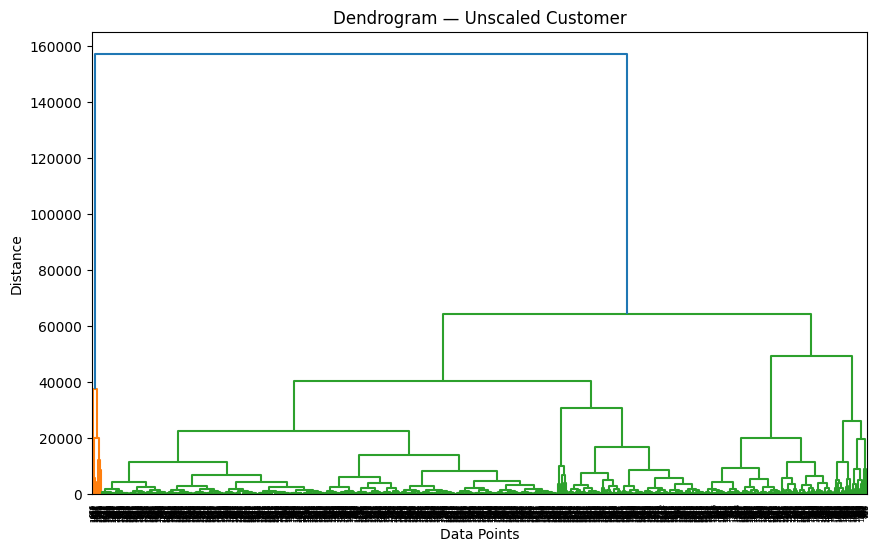

In [16]:
# Hierarchical clustering dendrogram for unscaled customer data
linked = linkage(df_model.values, method='average', metric='euclidean')

plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title("Dendrogram — Unscaled Customer")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [17]:
# Agglomerative clustering grid search on unscaled customer data
X = df_model.values
metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'average', 'complete']
distance_thresholds = [2, 4, 6, 8, 10]

best_score = -1
best_params = None
results = []

print("Running Agglomerative Grid Search (Unscaled)...\n")

# Grid search over metrics, linkage methods, and distance thresholds
for metric in metrics:
    for linkage_method in linkages:
        if linkage_method == 'ward' and metric != 'euclidean':
            continue  # Ward requires Euclidean
        for dist in distance_thresholds:
            try:
                agg = AgglomerativeClustering(
                    n_clusters=None,
                    distance_threshold=dist,
                    metric=metric,
                    linkage=linkage_method
                )
                labels = agg.fit_predict(X)

                # Skip results with fewer than 2 clusters
                if len(np.unique(labels)) < 2:
                    continue

                # Compute silhouette score
                sil = silhouette_score(X, labels)
                results.append((metric, linkage_method, dist, sil))

                print(f"Metric={metric}, Linkage={linkage_method}, Distance={dist}, Silhouette={sil:.4f}")

                # Track best configuration
                if sil > best_score:
                    best_score = sil
                    best_params = (metric, linkage_method, dist)
            except:
                continue

# Store best silhouette score for unscaled Agglomerative clustering
best_silhouette_agg_unscaled = best_score

print("\nBest Parameters:", best_params)
print("Best Silhouette Score:", best_score)

# Fit and label best clustering result
metric, linkage_method, dist = best_params
agg_best = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=dist,
    metric=metric,
    linkage=linkage_method
)
labels_best = agg_best.fit_predict(X)

Running Agglomerative Grid Search (Unscaled)...

Metric=euclidean, Linkage=ward, Distance=2, Silhouette=0.0012
Metric=euclidean, Linkage=ward, Distance=4, Silhouette=0.0179
Metric=euclidean, Linkage=ward, Distance=6, Silhouette=0.0374
Metric=euclidean, Linkage=ward, Distance=8, Silhouette=0.0673
Metric=euclidean, Linkage=ward, Distance=10, Silhouette=0.0886
Metric=euclidean, Linkage=average, Distance=2, Silhouette=0.0012
Metric=euclidean, Linkage=average, Distance=4, Silhouette=0.0179
Metric=euclidean, Linkage=average, Distance=6, Silhouette=0.0374
Metric=euclidean, Linkage=average, Distance=8, Silhouette=0.0679
Metric=euclidean, Linkage=average, Distance=10, Silhouette=0.0895
Metric=euclidean, Linkage=complete, Distance=2, Silhouette=0.0012
Metric=euclidean, Linkage=complete, Distance=4, Silhouette=0.0179
Metric=euclidean, Linkage=complete, Distance=6, Silhouette=0.0374
Metric=euclidean, Linkage=complete, Distance=8, Silhouette=0.0676
Metric=euclidean, Linkage=complete, Distance=10, S

### 3.6 DBSCAN Clustering — Scaled Data

Best DBSCAN configuration (≤10 clusters):
eps                   1.200000
min_samples           9.000000
clusters             18.000000
noise_points        138.000000
silhouette_score      0.251002
Name: 235, dtype: float64

Cluster counts:
Cluster
 2     404
 5     305
 3     290
 1     200
-1     138
 10     89
 6      87
 13     78
 9      61
 7      61
 4      59
 8      58
 12     46
 0      43
 11     20
 17     19
 14     18
 15     13
 16     11
Name: count, dtype: int64


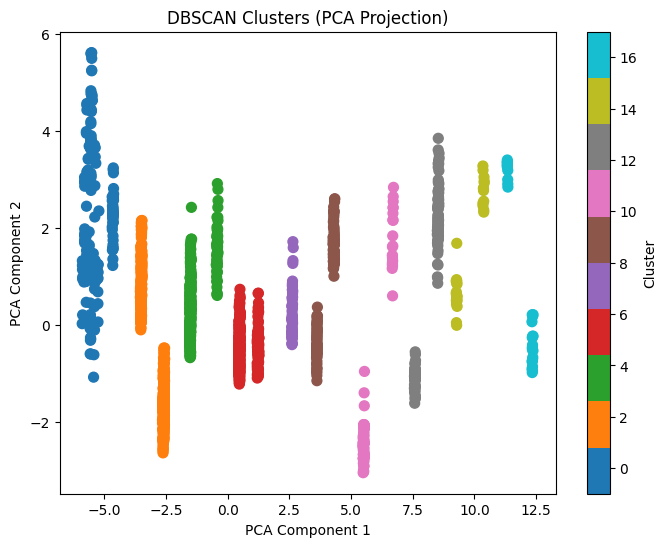

In [18]:
# 2. Run DBSCAN on a grid
# -----------------------------
results = []

eps_values = np.arange(0.1, 3.2, 0.1)       # eps from 0.1 to 3.1
min_samples_values = range(5, 26)           # min_samples 5-25

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(df_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_points = list(labels).count(-1)

        if n_clusters > 1:
            score = silhouette_score(df_scaled, labels)
        else:
            score = -1  # invalid silhouette for 1 cluster

        results.append([eps, min_samples, n_clusters, noise_points, score])

# Store results in a DataFrame
results_df = pd.DataFrame(results, columns=[
    "eps", "min_samples", "clusters", "noise_points", "silhouette_score"
])

# -----------------------------
# 3. Filter results for ≤10 clusters
# -----------------------------
filtered_results = results_df[(results_df["clusters"] <= 20) & (results_df["clusters"] >= 3)]
best_result = filtered_results.loc[filtered_results["silhouette_score"].idxmax()]

# Print only best DBSCAN configuration
print("Best DBSCAN configuration (≤10 clusters):")
print(best_result)

# -----------------------------
# 4. Run DBSCAN with best parameters
# -----------------------------
best_eps = best_result["eps"]
best_min_samples = int(best_result["min_samples"])

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
clusters = dbscan.fit_predict(df_scaled)

df_scaled["Cluster"] = clusters

# Print only cluster counts
print("\nCluster counts:")
print(df_scaled["Cluster"].value_counts())

# -----------------------------
# 5. PCA 2D plot
# -----------------------------
pca = PCA(n_components=2)
reduced_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(8,6))
plt.scatter(reduced_pca[:,0], reduced_pca[:,1], c=clusters, cmap='tab10', s=50)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("DBSCAN Clusters (PCA Projection)")
plt.colorbar(label='Cluster')
plt.show()

### 3.7 DBSCAN Clustering — Unscaled Data

Best eps: 0.30000000000000004
Best min_samples: 14
Best silhouette score: 0.704011155841568


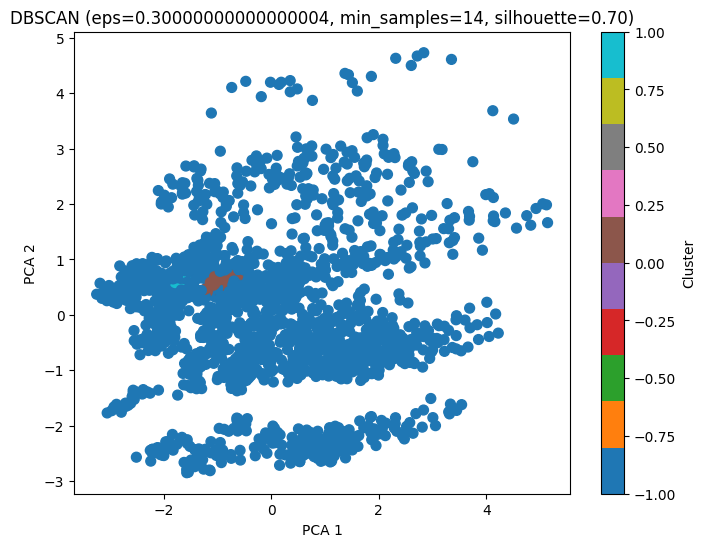

In [19]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Scale data
X = StandardScaler().fit_transform(df.values)

best_score = -1
best_eps = None
best_min_samples = None
best_labels = None

# Parameter ranges (important to keep realistic)
eps_values = np.arange(0.2, 1.6, 0.1)
min_samples_values = range(5, 21)

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)

        # Remove noise points
        mask = labels != -1

        # Valid clustering check
        if np.sum(mask) > 1 and len(set(labels[mask])) > 1:
            score = silhouette_score(X[mask], labels[mask])

            if score > best_score:
                best_score = score
                best_eps = eps
                best_min_samples = min_samples
                best_labels = labels

# Handle case where no valid clustering is found
if best_labels is None:
    print("No valid clustering found.")
else:
    print(f"Best eps: {best_eps}")
    print(f"Best min_samples: {best_min_samples}")
    print(f"Best silhouette score: {best_score}")

    # Step 3: PCA visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=best_labels, cmap='tab10', s=50)
    plt.title(f'DBSCAN (eps={best_eps}, min_samples={best_min_samples}, silhouette={best_score:.2f})')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.colorbar(label='Cluster')
    plt.show()

Iris Summary & Comparison

1.Best-performing clustering approaches
Based on the results, the clustering methods that performed best were KMeans on the unscaled dataset and DBSCAN on the scaled dataset. KMeans with unscaled data achieved a silhouette score of 0.5834 with 2 clusters, indicating clear separation between clusters. DBSCAN with scaled data achieved the highest silhouette score of 0.6117, although it produced 18 clusters with 47.45% noise points.

Agglomerative clustering either produced an excessively high number of clusters (97 clusters when scaled) or a very low silhouette score when unscaled (0.0895), indicating poor cluster separation. Therefore, KMeans (unscaled) and DBSCAN (scaled) were identified as the most suitable approaches for this dataset.

2.Comparison between KMeans, Hierarchical, and DBSCAN

KMeans: Partitions the dataset into a predefined number of clusters by minimizing distances between points and cluster centroids. It works best with spherical, evenly sized clusters. On the Iris dataset, KMeans performed well with unscaled data, achieving a silhouette score of 0.5834 with 2 clusters. However, scaling increased the number of clusters to 9 and reduced the silhouette score to 0.3019, showing less clear separation.

Hierarchical (Agglomerative) clustering: Builds clusters by progressively merging data points based on a chosen distance metric and linkage method. It provides flexibility in distance measures but produced 97 clusters when scaled, suggesting over-fragmentation. With unscaled data, the silhouette score dropped to 0.0895, indicating very weak clustering structure.

DBSCAN: Groups points based on density rather than distances to centroids. It can detect arbitrarily shaped clusters and identify noise points. On this dataset, scaled DBSCAN achieved the highest silhouette score of 0.6117, but generated 18 clusters and a large proportion of noise (47.45%). Without scaling, DBSCAN failed to form meaningful clusters due to feature range disparities.

3.Hyperparameter tuning for best clustering

KMeans: Tuned the number of clusters
𝐾
K by testing multiple values and computing the silhouette score. The value producing the highest score was selected: K = 2 for unscaled, K = 9 for scaled.

Agglomerative clustering: Evaluated combinations of distance metrics (Euclidean, Manhattan), linkage methods (e.g., average), and number of clusters. The configuration with the highest silhouette score was selected.

DBSCAN: Conducted a grid search over eps and min_samples, calculating the silhouette score for each combination while ensuring noise points did not exceed 50% of the dataset. Best parameters: eps = 0.4, min_samples = 15, producing a silhouette score of 0.6117.

4.Effect of distance functions
Distance functions influence how similarity between points is measured. For Agglomerative clustering, Manhattan distance on the scaled dataset produced a higher silhouette score (0.4437) than Euclidean distance on unscaled data (0.0895). Manhattan distance measures absolute differences and can perform better with features having different distributions. Euclidean distance is sensitive to large value differences, explaining poor unscaled performance.

5.Performance evaluation

Primary metric: Silhouette score, measuring intra-cluster cohesion vs inter-cluster separation. Higher is better.

Additional factors:

Number of clusters produced

Number and percentage of noise points (for DBSCAN)

Visual inspection of clusters using PCA projections

By combining quantitative metrics and visual inspection, the most meaningful clustering method was determined.

6.Visualization
Clusters were visualized using PCA to reduce the dataset to two dimensions. Each clustering method—KMeans, Agglomerative, and DBSCAN—was plotted in PCA space. Points were colored by cluster assignment, with DBSCAN noise points highlighted separately. These visualizations illustrate cluster separation and allow qualitative comparison.

7.Effect of scaling on clustering performance
Scaling significantly impacted clustering results. Without scaling, features with larger numerical ranges dominated distance calculations:

KMeans: Performed better without scaling, achieving a silhouette score of 0.5834. Scaling reduced the score to 0.3019.


Overall, scaling matters more when feature ranges differ substantially. For the Iris dataset, scaling slightly affected silhouette scores but did not drastically change cluster patterns.